# Практическая работа № 3

**Цель работы:** разработать и обучить модель условной генеративно-состязательной сети (Conditional GAN) для направленной генерации изображений собак различных пород, а также проанализировать качество полученных результатов и стабильность процесса обучения.

**Задачи:**

1. Реализовать генератор, создающий изображения собак по случайному шуму и заданной породе.
2. Реализовать дискриминатор, определяющий, является ли изображение настоящим и соответствует ли оно указанной породе.
3. Обучить Conditional GAN на датасете.
4. Визуализировать промежуточные результаты генерации.
5. Проанализировать качество полученных изображений и стабильность обучения модели.


---



**Теоретическая справка**

Генеративно-состязательные сети (GAN) — это архитектура нейронных сетей, предназначенная для генерации новых данных, похожих на реальные. GAN состоит из двух моделей: генератора и дискриминатора, которые обучаются одновременно в процессе соревнования друг с другом.

Генератор получает на вход случайный вектор шума и пытается создать реалистичное изображение. Его задача научиться генерировать изображения, максимально похожие на настоящие из датасета. Дискриминатор получает изображение и определяет, является ли оно настоящим или сгенерированным. Он обучается отличать реальные изображения от поддельных, созданных генератором. Во время обучения генератор старается обмануть дискриминатор, а дискриминатор научиться лучше различать настоящие и сгенерированные изображения. В результате такого состязательного процесса качество генерации постепенно улучшается.

Conditional GAN отличается от обычной GAN тем, что в модель дополнительно передаётся информация о классе объекта. В данной работе такой дополнительной информацией является порода собаки. Благодаря этому генератор может создавать изображения не случайных собак, а собак определённой породы.

Информация о породе передаётся в модель с помощью меток классов. Метка преобразуется в векторное представление и объединяется со случайным шумом в генераторе. В дискриминаторе метка также используется вместе с изображением, чтобы модель проверяла не только реалистичность изображения, но и соответствие указанной породе.

**Используемые инструменты:**

* PyTorch — основной фреймворк для разработки и обучения нейронных сетей. Используется для создания архитектур генератора и дискриминатора, вычисления градиентов и обновления весов.
* Torchvision — библиотека для работы с компьютерным зрением. Используется для загрузки датасета, изменения размера изображений, нормализации и аугментации данных.
* NumPy — библиотека для работы с многомерными массивами. Применяется для подготовки данных и математических расчетов при анализе результатов.
* Matplotlib — инструмент для визуализации. Используется для вывода сгенерированных сеток изображений и построения графиков функций потерь.

**Основные функции, которые будут использоваться:**

* `nn.Conv2d, nn.ConvTranspose2d` — основные слои для обработки и создания изображений (свертки и транспонированные свертки).
* `nn.Embedding` — слой для преобразования номера породы в векторный вид, понятный нейросети.
* `torch.cat` — функция для объединения вектора шума/изображения с информацией о породе.
* `nn.BCELoss` —  функция потерь для обучения GAN.
* `optim.Adam` — алгоритм оптимизации весов сетей.
* `transforms.Compose, transforms.Normalize` — создание конвейера предобработки входных изображений.

In [61]:
# Используемые библиотеки
import gdown
import tarfile
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import numpy as np

## 1. Подготовка датасета

Для обучения Conditional GAN будет использоваться датасет изображений собак различных пород. Загрузим два архива: images.tar — изображения собак, annotation.tar — аннотации и информация о классах.

In [ ]:
!pip install gdown

In [ ]:
# Скачивание файлов
gdown.download(
    f"https://drive.google.com/uc?id=1mftPpFflz7vQ1h5756OWWjIempb1D85V",
    "images.tar",
    quiet=False
)

gdown.download(
    f"https://drive.google.com/uc?id=1uIiEBbg7cZrwVOo5woz86bEb7gkAkXdd",
    "annotation.tar",
    quiet=False
)

# Распаковка изображений
with tarfile.open("images.tar") as tar:
    tar.extractall("/content/")

# Распаковка аннотаций
with tarfile.open("annotation.tar") as tar:
    tar.extractall("/content/")

image_folders = os.listdir('/content/Images')

print("Количество пород:", len(image_folders))
print("\nПримеры папок с породами:\n")

for folder in image_folders[:10]:
    print(folder)

Downloading...
From (original): https://drive.google.com/uc?id=1mftPpFflz7vQ1h5756OWWjIempb1D85V
From (redirected): https://drive.google.com/uc?id=1mftPpFflz7vQ1h5756OWWjIempb1D85V&confirm=t&uuid=79d24f9f-8ef8-4e84-8853-36ed8fd9747d
To: /content/images.tar
100%|██████████| 794M/794M [00:11<00:00, 69.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1uIiEBbg7cZrwVOo5woz86bEb7gkAkXdd
From (redirected): https://drive.google.com/uc?id=1uIiEBbg7cZrwVOo5woz86bEb7gkAkXdd&confirm=t&uuid=88c4dcea-1272-4720-b6d2-513789a84224
To: /content/annotation.tar
100%|██████████| 21.9M/21.9M [00:00<00:00, 72.4MB/s]
/tmp/ipykernel_1708/3922270926.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/")
/tmp/ipykernel_1708/3922270926.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or

Количество пород: 120

Примеры папок с породами:

n02102973-Irish_water_spaniel
n02112137-chow
n02101388-Brittany_spaniel
n02096437-Dandie_Dinmont
n02107574-Greater_Swiss_Mountain_dog
n02113978-Mexican_hairless
n02106382-Bouvier_des_Flandres
n02099712-Labrador_retriever
n02091635-otterhound
n02096177-cairn


Посмотрим пример изображений.

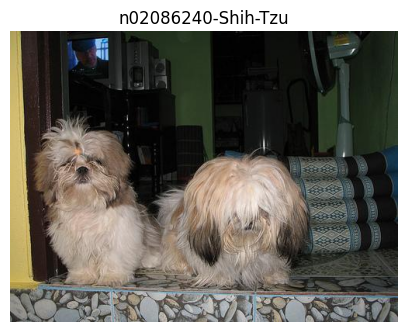

In [ ]:
# Случайная порода
breed_folder = random.choice(image_folders)

breed_path = os.path.join('/content/Images', breed_folder)

# Случайное изображение
image_name = random.choice(os.listdir(breed_path))
image_path = os.path.join(breed_path, image_name)

img = Image.open(image_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(breed_folder)
plt.axis('off')
plt.show()

Теперь нужно подготовить данные для обучения. Создадим список изображений и меток.

In [ ]:
image_paths = []
labels = []

breeds = sorted(os.listdir('/content/Images'))
breed_to_idx = {breed: idx for idx, breed in enumerate(breeds)}

for breed in breeds:
    breed_folder = os.path.join('/content/Images', breed)

    for img_name in os.listdir(breed_folder):
        img_path = os.path.join(breed_folder, img_name)

        image_paths.append(img_path)
        labels.append(breed_to_idx[breed])

print("Всего изображений:", len(image_paths))
print("Количество пород:", len(breeds))

Всего изображений: 20580
Количество пород: 120


Преобразуем изображения для работы с моделью, создадим Dataset и DataLoader.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [ ]:
class DogDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')

        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]

        return img, label

dataset = DogDataset(
    image_paths=image_paths,
    labels=labels,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

images, labels = next(iter(dataloader))

print("Размер батча изображений:", images.shape)
print("Размер батча меток:", labels.shape)

Размер батча изображений: torch.Size([64, 3, 64, 64])
Размер батча меток: torch.Size([64])


Изображения были распакованы и организованы по папкам, соответствующим породам собак. Для обучения модели каждому классу породы был присвоен числовой индекс. Изображения были приведены к размеру 64 на 64 пикселя, преобразованы в тензоры и нормализованы в диапазон [-1, 1].

## 2. Создание класса генератора

В Conditional GAN генератор не просто создает случайную картинку, а ориентируется на метку класса — породу собаки. Чтобы нейросеть понимала, какую именно породу нужно сгенерировать, используется слой Embedding. Он преобразует номер породы в вектор признаков, который объединяется со случайным шумом. Благодаря этому генератор получает информацию не только о случайных особенностях изображения, но и о нужном классе.

Для более стабильного обучения также используется специальная инициализация весов (weights_init). Она задает начальные значения весов сверточных слоев и Batch Normalization, что помогает генератору и дискриминатору быстрее и стабильнее обучаться.

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super(Generator, self).__init__()

        # Слой эмбеддинга для пород собак
        self.label_emb = nn.Embedding(num_classes, latent_dim)

        # Входной слой: шум + эмбеддинг
        self.init_size = 64 // 16 # Начинаем с маленького разрешения
        self.l1 = nn.Sequential(nn.Linear(latent_dim * 2, 512 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(512),
            # 4x4 в 8x8
            nn.Upsample(scale_factor=2),
            nn.Conv2d(512, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            # 8x8 в 16x16
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            # 16x16 в 32x32
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            # 32x32 в 64x64
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 3, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        # Объединяем вектор шума и эмбеддинг метки породы
        gen_input = torch.cat((self.label_emb(labels), noise), -1)
        # Прогоняем через полносвязный слой и меняем форму под тензор изображения
        out = self.l1(gen_input)
        out = out.view(out.shape[0], 512, self.init_size, self.init_size)
        # Постепенно увеличиваем разрешение до 64x64
        img = self.conv_blocks(out)
        return img

Генератор построен по принципу глубокой сверточной нейронной сети с добавлением условия по классу.
* nn.Embedding переводит дискретный номер породы в векторное пространство. Такой вектор содержит информацию о характерных признаках породы, которые сеть должна учитывать при генерации.
* Полносвязный слой nn.Linear принимает объединенный вектор шума и embedding-вектор породы, после чего преобразует его в большое количество признаков, которые затем интерпретируются как маленькая карта признаков.
* Слои nn.Upsample и nn.Conv2d используются для постепенного увеличения разрешения изображения. Сеть берет маленькое абстрактное изображение и слой за слоем дорисовывает детали.
* nn.BatchNorm2d нормализует выходные данные слоев, предотвращая ситуацию, когда веса взрываются или затухают, что делает обучение стабильнее.
* В качестве функции активации используется nn.LeakyReLU, которая помогает сети обучать сложные нелинейные зависимости и снижает вероятность появления мертвых нейронов.
* Финальная активация nn.Tanh сжимает значения всех пикселей в диапазон [-1, 1], что соответствует нормализации изображений перед обучением.

## 3. Создание класса дискриминатора

Дискриминатор в cGAN решает двойную задачу: он должен понять, является ли изображение реалистичным, и соответствует ли оно указанной породе.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, num_classes, img_size=64):
        super(Discriminator, self).__init__()
        # Слой эмбеддинга для породы
        self.label_embedding = nn.Embedding(num_classes, 50)
        # Полносвязный слой, чтобы привести его к 1 каналу
        self.label_fc = nn.Linear(50, 1 * img_size * img_size)

        def discriminator_block(in_filters, out_filters, bn=True):
            block = [nn.Conv2d(in_filters, out_filters, 3, 2, 1),
                     nn.LeakyReLU(0.2, inplace=True),
                     nn.Dropout2d(0.25)]
            if bn: block.append(nn.BatchNorm2d(out_filters, 0.8))
            return block

        # Вход: 3 канала изображения + 1 канал для метки (в виде доп. слоя)
        self.model = nn.Sequential(
            *discriminator_block(3 + 1, 64, bn=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
        )

        # Выходной слой: классификация
        self.adv_layer = nn.Sequential(
            nn.Linear(512 * (img_size // 16)**2, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Получаем эмбеддинг
        le = self.label_embedding(labels)
        # Растягиваем его в размер изображения
        le = self.label_fc(le).view(le.size(0), 1, img.size(2), img.size(3))
        # Склеиваем
        d_in = torch.cat((img, le), 1)
        validity = self.model(d_in)
        validity = validity.view(validity.size(0), -1)
        return self.adv_layer(validity)

В обычной GAN дискриминатор видит только пиксели, в Conditional GAN используется метод конкатенации каналов. Номер породы превращается в числовой вектор, с помощью полносвязного слоя этот вектор разворачивается в отдельный канал размером с изображение. Затем данный канал объединяется с изображением по каналам, дискриминатор получает на вход не только RGB-изображение, но и дополнительный канал с информацией о породе. Благодаря этому фильтры нейросети учатся распознавать закономерности: например, если в 4-м канале код «Хаски», а в первых трех нет признаков хаски, дискриминатор снижает оценку достоверности.

Сверточные слои nn.Conv2d постепенно извлекают признаки изображения, уменьшая его пространственный размер и выделяя более сложные структуры, такие как контуры, текстуры и формы. Функция активации nn.LeakyReLU добавляет нелинейность и помогает избежать проблемы мертвых нейронов при обучении. Слой nn.Dropout2d используется для регуляризации и уменьшения переобучения дискриминатора. nn.BatchNorm2d стабилизирует распределение признаков между слоями и делает обучение более устойчивым. После прохождения через сверточные блоки признаки преобразуются в вектор и передаются в финальный полносвязный слой классификации. Последняя функция активации nn.Sigmoid переводит результат в диапазон от 0 до 1.

## 4.  Функция обучения Conditional GAN

Обучение Conditional GAN. Создаются генератор и дискриминатор, после чего для них выполняется специальная инициализация весов для более стабильного обучения. Во время обучения дискриминатор учится отличать реальные изображения собак от сгенерированных и проверять соответствие породе. Генератор, наоборот, пытается создавать изображения собак, которые будут выглядеть реалистично и смогут обмануть дискриминатор. Обучение происходит поочередно: сначала обновляется дискриминатор на реальных и фейковых изображениях, затем обучается генератор, стремящийся повысить качество генерации.

Для оценки процесса обучения сохраняются ошибки генератора и дискриминатора. Через несколько эпох выводятся промежуточные результаты генерации.

In [ ]:
def train_gan(dataloader, generator, discriminator, n_epochs, latent_dim):
    # Инициализация функции потерь
    adversarial_loss = nn.BCELoss()
    # Инициализация оптимизаторов
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999)) # Для 1 эксперимента было lr=0.0002
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999)) # Для 1 эксперимента было lr=0.0002

    # Списки для сохранения истории ошибок
    g_losses = []
    d_losses = []

    # Фиксированный шум и метки для отслеживания прогресса
    fixed_noise = torch.randn(16, latent_dim).to(device)
    fixed_labels = torch.randint(0, num_classes, (16,)).to(device)

    for epoch in range(n_epochs):
        for i, (imgs, labels) in enumerate(dataloader):

            batch_size = imgs.shape[0]
            real_imgs = imgs.to(device)
            labels = labels.to(device)

            # Создаем ответы для дискриминатора
            valid = torch.ones(batch_size, 1).to(device)  # 1 = настоящее
            fake = torch.zeros(batch_size, 1).to(device)   # 0 = подделка

            # Обучение Дискриминатора
            optimizer_D.zero_grad()

            # Ошибка на реальных изображениях
            output_real = discriminator(real_imgs, labels)
            loss_real = adversarial_loss(output_real, valid)

            # Генерируем фейковые изображения
            z = torch.randn(batch_size, latent_dim).to(device)
            gen_labels = torch.randint(0, num_classes, (batch_size,)).to(device)
            gen_imgs = generator(z, gen_labels)

            # Ошибка на фейковых изображениях
            output_fake = discriminator(gen_imgs.detach(), gen_labels)
            loss_fake = adversarial_loss(output_fake, fake)

            # Суммарная ошибка дискриминатора
            d_loss = (loss_real + loss_fake) / 2
            d_loss.backward()
            optimizer_D.step()

            # Обучение Генератора
            optimizer_G.zero_grad()
            output_g = discriminator(gen_imgs, gen_labels)
            g_loss = adversarial_loss(output_g, valid)
            g_loss.backward()
            optimizer_G.step()

            # Сохраняем ошибки для графиков
            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

            if i == len(dataloader) - 1:
              print(f"[Epoch {epoch}/{n_epochs}] [D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

        # Вывод промежуточных результатов
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            visualize_progress(generator, fixed_noise, fixed_labels, epoch)

    return g_losses, d_losses

def visualize_progress(gen, noise, labels, epoch):
    gen.eval()
    with torch.no_grad():
        gen_imgs = gen(noise, labels)
        gen_imgs = gen_imgs * 0.5 + 0.5 # Денормализация
        grid = make_grid(gen_imgs, nrow=4).cpu().numpy()
        plt.figure(figsize=(8,8))
        plt.imshow(np.transpose(grid, (1, 2, 0)))
        plt.title(f"Generated Images - Epoch {epoch}")
        plt.axis('off')
        plt.show()
    gen.train()

In [ ]:
# Параметры обучения
latent_dim = 100
n_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(breeds)
# Инициализация моделей
generator = Generator(num_classes, latent_dim).to(device)
discriminator = Discriminator(num_classes).to(device)

# Применение весов
generator.apply(weights_init)
discriminator.apply(weights_init)

g_loss_history, d_loss_history = train_gan(dataloader, generator, discriminator, n_epochs, latent_dim)

Output hidden; open in https://colab.research.google.com to view.

Обучение на всех 100 эпохах не завершилось из-за ограничения на использование GPU, но по 80 эпохам видно, что модели не удалось научиться генерации собак 120 разных пород. По значениям Loss видно, что график потерь был бы с большими колебаниями и скачками, обучение нестабильное. Это типичное поведение для GAN: как только генератор находит способ обмануть дискриминатор, тот меняется, заставляя генератор искать новые пути. В данном случае система не пришла к равновесию.   


Основные возможные причины неудачной генерации это чрезмерная сложность задачи: модель пытается выучить распределение 120 разных классов одновременно. При текущей глубине нейросети ей не хватает емкости, чтобы запомнить тонкие различия. Собаки одной и той же породы могут быть сняты с разных ракурсов, в разном освещении и позах, что для GAN создает огромный шум. И недостаток итераций обучения, 80-100 эпох для 120 классов на базовой архитектуре оказалось мало.

В итоге, на изображениях видны только цветовые пятна, соответствующие фону (зеленый, вероятно, трава) и общим очертаниям тел (коричневые/белые пятна), но детализация морфологических признаков отсутствует.

*График обучения был такой, но я случайно удалила ячейку и перезапускать обучение заново не стала, так как оно долго выполнялось.*

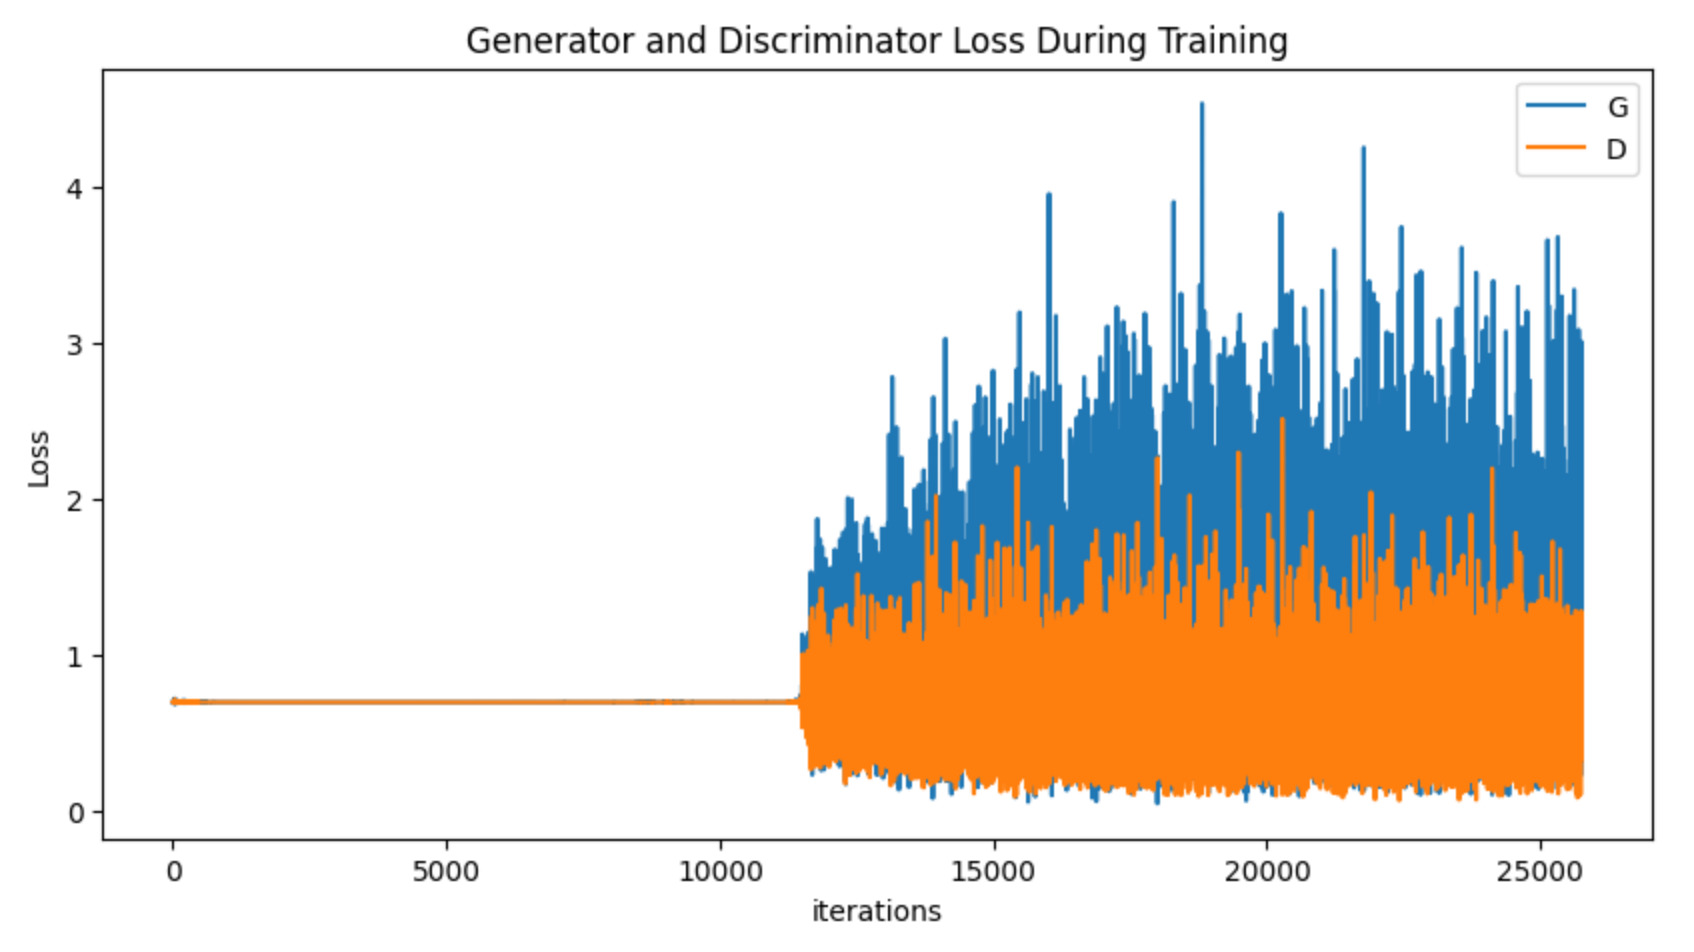

## 5. Обучение на нескольких породах

Попробуем обучение на 2 визуально отличимых породах. Модель сосредоточится на узком наборе признаков. Обучение пойдет быстрее, и GPU лимита хватит, чтобы увидеть прогресс.

Отфильтруем текущие списки image_paths и labels, оставим 2 породы, которые сильно отличаются друг от друга.

In [ ]:
target_keywords = ['beagle', 'pomeranian']

new_image_paths = []
new_labels = []

# Словарь для новых индексов
breed_to_idx_small = {keyword: i for i, keyword in enumerate(target_keywords)}

for path in image_paths:
    folder_name = path.split('/')[-2].lower()

    for keyword in target_keywords:
        if keyword in folder_name:
            new_image_paths.append(path)
            new_labels.append(breed_to_idx_small[keyword])
            break

# Обновляем количество классов для моделей
num_classes = len(target_keywords)
breeds_small = target_keywords

print(f"Отобрано изображений: {len(new_image_paths)}")
print(f"Породы для обучения: {breeds_small}")

# Пересоздаем Dataset и DataLoader
small_dataset = DogDataset(
    image_paths=new_image_paths,
    labels=new_labels,
    transform=transform
)

small_dataloader = DataLoader(
    small_dataset,
    batch_size=64,
    shuffle=True
)

Отобрано изображений: 414
Породы для обучения: ['beagle', 'pomeranian']


Так как теперь классов всего 2, нужно создать новые экземпляры Generator и Discriminator. И запустим обучение на 200 эпох.

In [ ]:
latent_dim = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator(num_classes, latent_dim).to(device)
discriminator = Discriminator(num_classes).to(device)

# Инициализация весов
generator.apply(weights_init)
discriminator.apply(weights_init)

# Обучение на 200 эпох
g_loss_history, d_loss_history = train_gan(small_dataloader, generator, discriminator, n_epochs=200, latent_dim=100)

Output hidden; open in https://colab.research.google.com to view.

Визуализация графиков функции потерь для генератора и дискриминатора.

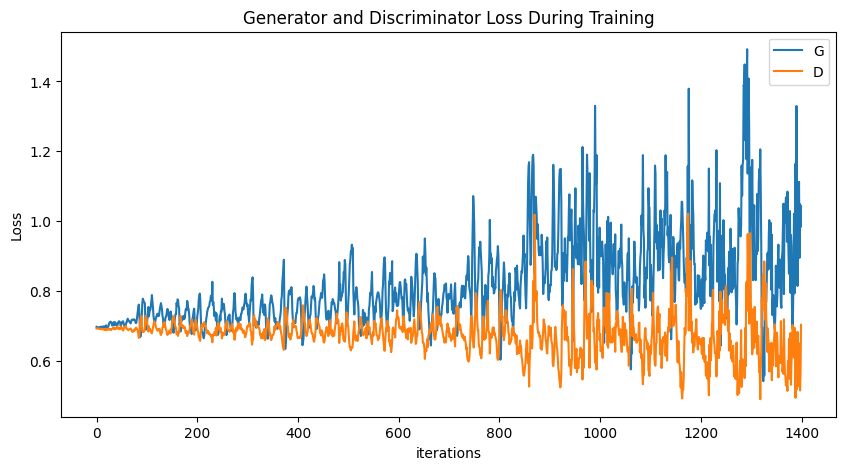

In [ ]:
def plot_losses(g_losses, d_losses):
    plt.figure(figsize=(10, 5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(g_losses, label="G")
    plt.plot(d_losses, label="D")
    plt.xlabel("iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_losses(g_loss_history, d_loss_history)

На данных двух отличимых пород тоже не удалось обучить модель генерировать изображения собак. На финальных этапах сгенерированные изображения представляют собой абстрактные цветовые формы, в которых не прослеживаются даже основные цветовые гаммы выбранных пород, в отличии от 1 эксперимента.

Главная причина этого наглядно видна на графике лосса, после 200 итерации кривые начинают стабильно расходиться. Лосс дискриминатора падает, а лосс генератора растет. Это ситуация доминирования дискриминатора, при которой критик становится слишком сильным и перестает давать генератору информативные градиенты для прорисовки деталей. Стандартной сверточной сети не хватает механизмов внимания и более стабильной функции потерь, чтобы выучить сложные биологические формы.

Функция для сопоставления полученных изображений с реальными фото из датасета.

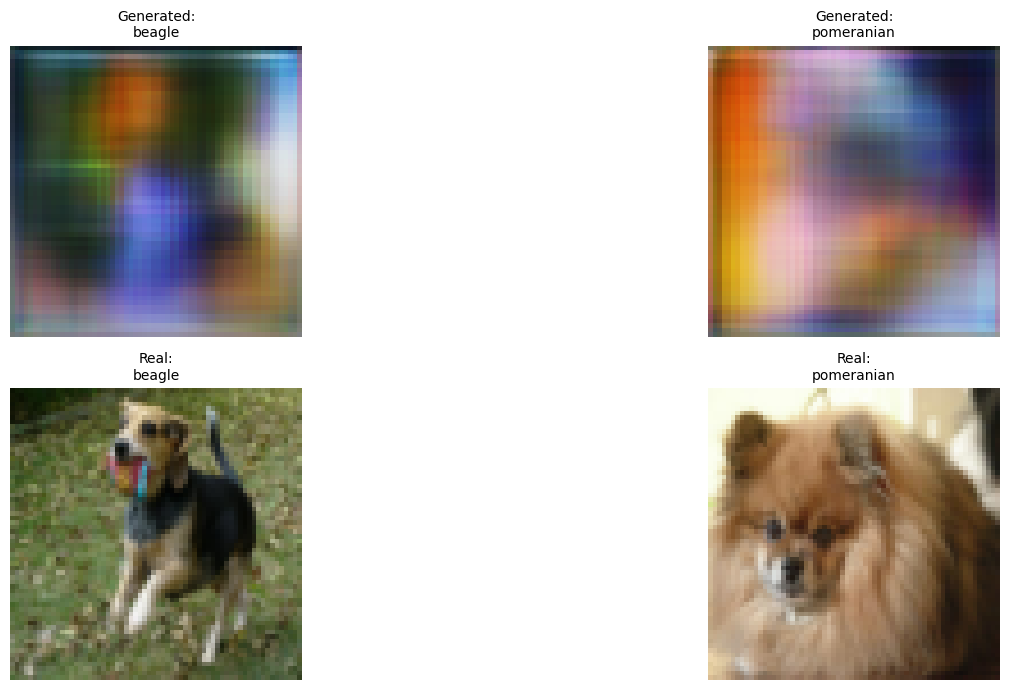

In [ ]:
def final_compare_breeds(generator, dataset, breeds_list):
    generator.eval()
    num_breeds = len(breeds_list)
    plt.figure(figsize=(18, 7))

    for i in range(num_breeds):
        # Генерируем изображение для текущей породы
        noise = torch.randn(1, latent_dim).to(device)
        label = torch.LongTensor([i]).to(device)

        with torch.no_grad():
            gen_img = generator(noise, label).cpu()
            gen_img = gen_img.squeeze(0) * 0.5 + 0.5 # Денормализация

        # Рисуем сгенерированное
        plt.subplot(2, num_breeds, i + 1)
        plt.imshow(np.transpose(gen_img.numpy(), (1, 2, 0)))
        # Убираем технические префиксы из названия
        clean_name = breeds_list[i].split('-', 1)[-1].replace('_', ' ')
        plt.title(f"Generated:\n{clean_name}", fontsize=10)
        plt.axis('off')

        # Реальное изображение этой же породы из датасета
        real_img_idx = next(idx for idx, l in enumerate(dataset.labels) if l == i)
        real_img, _ = dataset[real_img_idx]
        real_img = real_img * 0.5 + 0.5 # Денормализация

        plt.subplot(2, num_breeds, i + 1 + num_breeds)
        plt.imshow(np.transpose(real_img.numpy(), (1, 2, 0)))
        plt.title(f"Real:\n{clean_name}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

final_compare_breeds(generator, small_dataset, breeds_small)

## Вывод

В рамках данной работы была реализована и исследована архитектура условной генеративно-состязательной сети (cDCGAN) для задачи генерации изображений собак на основе набора данных Stanford Dogs. В ходе серии экспериментов были протестированы различные конфигурации гиперпараметров, варьировалось количество целевых классов и длительность обучения. Итоговый анализ показал, что даже при существенном упрощении задачи модель не достигла хороших результатов.

Ключевым выводом работы стало выявление ограничения выбранной архитектуры: стандартные сверточные слои DCGAN справляются с передачей цветовых схем и общих силуэтов объектов, но оказываются недостаточно эффективными для сложной геометрии. Графики функции потерь иллюстрируют проблему доминирования дискриминатора, при которой критик слишком быстро обучается отличать подделки, лишая генератор полезного обучающего сигнала и приводя к затуханию градиентов.

Полученные результаты подчеркивают, что простое увеличение количества эпох обучения не является решением для стабилизации GAN-систем. Для качественного улучшения генерации требуется внедрение более продвинутых методов регуляризации и функций потерь. Тем не менее, проделанная работа позволила глубоко изучить внутреннюю архитектуру сетей, проблемы при обучении и возможные методы их отладки.